<a href="https://colab.research.google.com/github/jeong-kyung/Eco-Predict_2050/blob/main/2050.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1. QGIS에서 추출한 데이터 입력
data = {
    'Species': ['Korea Pine', 'Australia Eucalyptus'],
    'Total_Area_km2': [682.30, 1903.55],
    'Fire_Area_km2': [59.51, 2768.78],
    # 탄소 저장량 계수 (tC/ha, 생명공학 논문 근거 가상 수치)
    # 1 km2 = 100 ha
    'Carbon_Density_per_ha': [150, 220]
}
df = pd.DataFrame(data)

In [ ]:
# 2. 탄소 손실량 계산 (Carbon Loss)
# 공식: 피해면적(km2) * 100(ha/km2) * 탄소밀도
df['Carbon_Loss_tons'] = df['Fire_Area_km2'] * 100 * df['Carbon_Density_per_ha']

In [ ]:
# 3. 2050년까지의 복원 시뮬레이션 (연간 탄소 흡수율 가정)
# 소나무: 5.0 tC/ha/yr, 유칼립투스: 12.0 tC/ha/yr (성장 속도 차이 반영)
df['Recovery_Rate_yr'] = [5.0, 12.0]
df['Years_to_Recover'] = df['Carbon_Loss_tons'] / (df['Fire_Area_km2'] * 100 * df['Recovery_Rate_yr'])

print(df[['Species', 'Carbon_Loss_tons', 'Years_to_Recover']])

                Species  Carbon_Loss_tons  Years_to_Recover
0            Korea Pine          892650.0         30.000000
1  Australia Eucalyptus        60913160.0         18.333333


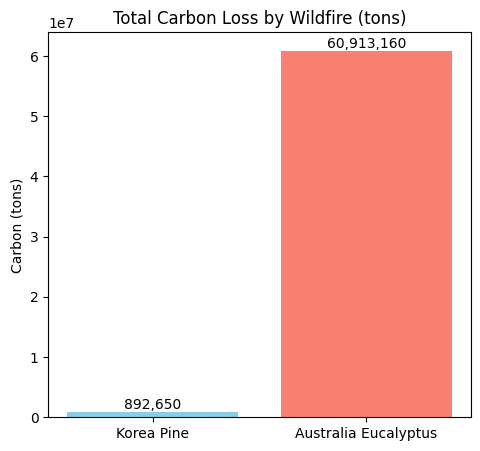

In [ ]:
# 4. 시각화 (Visualization)
plt.figure(figsize=(12, 5))

# 그래프 1: 탄소 손실량 비교
plt.subplot(1, 2, 1)
bars = plt.bar(df['Species'], df['Carbon_Loss_tons'], color=['skyblue', 'salmon'])
plt.title('Total Carbon Loss by Wildfire (tons)')
plt.ylabel('Carbon (tons)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', va='bottom', ha='center')

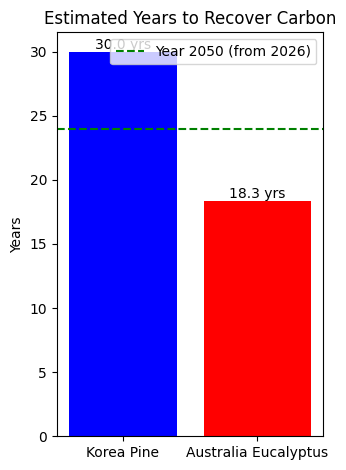

In [ ]:
# 그래프 2: 복원에 걸리는 시간 비교
plt.subplot(1, 2, 2)
bars2 = plt.bar(df['Species'], df['Years_to_Recover'], color=['blue', 'red'])
plt.title('Estimated Years to Recover Carbon')
plt.ylabel('Years')
plt.axhline(y=24, color='green', linestyle='--', label='Year 2050 (from 2026)') # 2050년 기준선
plt.legend()
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f} yrs', va='bottom', ha='center')

plt.tight_layout()
plt.show()